# Stage 6 – LSTM Form Classifier
## Notebook 3: Real-time Inference on Video

End-to-end push-up form analysis on a video file:

```
Frame
 └─ Person Detector  (YOLO11m)      → person bbox
      └─ Pose Estimator (YOLOv8n-pose) → 17 keypoints
           └─ Feature Extraction         → 15 features/frame
                └─ Rep Detection          → valley in elbow angle
                     └─ LSTM Classifier   → correct / wrong + confidence
```

**Output:** annotated video with skeleton, rep counter, form verdict.

In [12]:
# ── 3.0  Imports ──────────────────────────────────────────────────────────────
import json, time, collections
from pathlib import Path

import cv2
import numpy as np
import torch
import torch.nn as nn
from scipy.interpolate import interp1d
from scipy.signal import find_peaks
from ultralytics import YOLO

DEVICE = (
    torch.device('mps')  if torch.backends.mps.is_available() else
    torch.device('cuda') if torch.cuda.is_available()         else
    torch.device('cpu')
)
print(f'Device: {DEVICE}')
print(f'OpenCV: {cv2.__version__}')

Device: mps
OpenCV: 4.13.0


In [13]:
# ── 3.1  Paths (edit INPUT_VIDEO to point at your clip) ───────────────────────
ROOT       = Path('..').resolve()
MODEL_DIR  = Path('.') / 'models'

# ── Person detector ──────────────────────────────────────────────────────────
PD_INFO      = json.loads((ROOT / 'person_detector/models/best_model/best_model_info.json').read_text())
PD_MODEL_PATH = Path(PD_INFO['pt_path'])
PD_CONF      = PD_INFO['conf_thresh']

# ── Pose estimator ───────────────────────────────────────────────────────────
POSE_JSON  = json.loads((ROOT / 'keypoint_detector/best_model_choice.json').read_text())
POSE_ID    = POSE_JSON['model_id']      # 'yolov8n-pose.pt'
POSE_PATH  = ROOT / 'keypoint_detector' / POSE_ID

# ── LSTM classifier ──────────────────────────────────────────────────────────
LSTM_CKPT  = MODEL_DIR / 'best_model.pt'
LSTM_CFG   = json.loads((MODEL_DIR / 'model_config.json').read_text())

# ── Input / output video ─────────────────────────────────────────────────────
# Set this to your video file or 0 for webcam
INPUT_VIDEO  = str(ROOT / 'data' / 'correct_form' / sorted(
    (ROOT / 'data' / 'correct_form').glob('*.mp4')
)[0])  if any((ROOT / 'data' / 'correct_form').glob('*.mp4')) else ''

OUTPUT_VIDEO = str(MODEL_DIR / 'inference_output.mp4')

print(f'Person detector : {PD_MODEL_PATH.name}')
print(f'Pose model      : {POSE_ID}')
print(f'LSTM model      : {LSTM_CKPT}')
print(f'Input video     : {INPUT_VIDEO or "[WEBCAM]"}')
print(f'Output video    : {OUTPUT_VIDEO}')

Person detector : best_model.pt
Pose model      : yolov8n-pose.pt
LSTM model      : models/best_model.pt
Input video     : /Users/haleytran/Downloads/pushup_judge/data/correct_form/Copy of push up 1.mp4
Output video    : models/inference_output.mp4


## 3.2  Load Models

In [14]:
# ── 3.2  Load all models ───────────────────────────────────────────────────────

# Person detector
person_model = YOLO(str(PD_MODEL_PATH))
print('Person detector loaded.')

# Pose estimator
pose_model = YOLO(str(POSE_PATH))
print('Pose estimator loaded.')

# LSTM classifier
class PushupLSTM(nn.Module):
    def __init__(self, n_features, hidden=64, n_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features, hidden_size=hidden,
            num_layers=n_layers, dropout=dropout if n_layers>1 else 0.0,
            batch_first=True, bidirectional=True
        )
        d = hidden * 2
        self.norm  = nn.LayerNorm(d)
        self.drop1 = nn.Dropout(dropout)
        self.fc1   = nn.Linear(d, 64)
        self.relu  = nn.ReLU()
        self.drop2 = nn.Dropout(0.2)
        self.fc2   = nn.Linear(64, 1)

    def forward(self, x):
        _, (h, _) = self.lstm(x)
        h_cat = torch.cat([h[-2], h[-1]], dim=1)
        return self.fc2(self.drop2(self.relu(self.fc1(self.drop1(self.norm(h_cat)))))).squeeze(1)

lstm_model = PushupLSTM(
    n_features = LSTM_CFG['n_features'],
    hidden     = LSTM_CFG['hidden'],
    n_layers   = LSTM_CFG['n_layers'],
    dropout    = LSTM_CFG['dropout'],
).to(DEVICE)
ckpt = torch.load(LSTM_CKPT, map_location=DEVICE)
lstm_model.load_state_dict(ckpt['model_state'])
lstm_model.eval()

THRESHOLD    = LSTM_CFG['threshold']
FEATURE_COLS = LSTM_CFG['feature_cols']
FEAT_MEAN    = np.array(LSTM_CFG['feat_mean'], dtype=np.float32)
FEAT_STD     = np.array(LSTM_CFG['feat_std'],  dtype=np.float32)
T_FIXED      = LSTM_CFG['T_fixed']
F_DIM        = LSTM_CFG['n_features']

print(f'LSTM loaded  (T_fixed={T_FIXED}  F={F_DIM}  threshold={THRESHOLD})')

Person detector loaded.
Pose estimator loaded.
LSTM loaded  (T_fixed=20  F=15  threshold=0.5)


## 3.3  Feature Extraction Helpers

Exact same code as `feature_engineering/1.feature_engineering.ipynb`.

In [ ]:
# ── 3.3  Feature helpers (inlined from stage 3 notebook) ──────────────────────

CONF_THRESH = 0.3   # must match training pipeline (was wrongly set to 0.7)
NAN_FRAME   = {col: np.nan for col in FEATURE_COLS}

def angle_3pts(a, b, c):
    ba = np.asarray(a, float) - np.asarray(b, float)
    bc = np.asarray(c, float) - np.asarray(b, float)
    n  = np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-9
    return float(np.degrees(np.arccos(np.clip(np.dot(ba, bc) / n, -1, 1))))

def perpendicular_dist(p, line_a, line_b):
    ab = line_b - line_a
    t  = np.dot(p - line_a, ab) / (np.dot(ab, ab) + 1e-9)
    return float(np.linalg.norm(p - (line_a + t * ab)))

def euclidean(a, b):
    return float(np.linalg.norm(np.asarray(a) - np.asarray(b)))


def extract_frame_features(kps: np.ndarray, img_h: int, img_w: int) -> dict:
    """kps: (17, 3) [x_px, y_px, conf]  → dict of 15 features."""
    H, W = float(img_h), float(img_w)

    def pt(i):
        if kps[i, 2] > CONF_THRESH:
            return np.array([kps[i,0]/W, kps[i,1]/H])
        return None

    nose=pt(0); l_sh=pt(5); r_sh=pt(6); l_el=pt(7); r_el=pt(8)
    l_wr=pt(9); r_wr=pt(10); l_hi=pt(11); r_hi=pt(12)
    l_kn=pt(13); r_kn=pt(14); l_an=pt(15); r_an=pt(16)

    d = dict(NAN_FRAME)

    if l_sh is not None and l_el is not None and l_wr is not None:
        d['left_elbow_angle']  = angle_3pts(l_sh, l_el, l_wr)
    if r_sh is not None and r_el is not None and r_wr is not None:
        d['right_elbow_angle'] = angle_3pts(r_sh, r_el, r_wr)
    vals = [v for v in [d['left_elbow_angle'], d['right_elbow_angle']] if not np.isnan(v)]
    d['mean_elbow_angle'] = float(np.mean(vals)) if vals else np.nan
    if not np.isnan(d['left_elbow_angle']) and not np.isnan(d['right_elbow_angle']):
        d['elbow_symmetry'] = abs(d['left_elbow_angle'] - d['right_elbow_angle'])

    if l_sh is not None and l_hi is not None and l_kn is not None:
        d['left_hip_angle']  = angle_3pts(l_sh, l_hi, l_kn)
    if r_sh is not None and r_hi is not None and r_kn is not None:
        d['right_hip_angle'] = angle_3pts(r_sh, r_hi, r_kn)

    for sh, hi, an in [(l_sh,l_hi,l_an),(r_sh,r_hi,r_an)]:
        if sh is not None and hi is not None and an is not None:
            d['body_straightness'] = perpendicular_dist(hi, sh, an); break

    sh_pts = [v for v in [l_sh, r_sh] if v is not None]
    hi_pts = [v for v in [l_hi, r_hi] if v is not None]
    if sh_pts: d['shoulder_height_norm'] = float(np.mean([p[1] for p in sh_pts]))
    if hi_pts: d['hip_height_norm']      = float(np.mean([p[1] for p in hi_pts]))

    if l_wr is not None and r_wr is not None:
        d['wrist_width_norm']    = euclidean(l_wr, r_wr)
    if l_sh is not None and r_sh is not None:
        d['shoulder_width_norm'] = euclidean(l_sh, r_sh)
    if nose is not None:
        d['nose_height_norm'] = float(nose[1])

    return d


def add_velocity_inplace(prev_feat: dict, cur_feat: dict):
    """Fill velocity features in cur_feat using prev_feat."""
    def delta(key):
        v_cur  = cur_feat.get(key, np.nan)
        v_prev = prev_feat.get(key, np.nan)
        if np.isnan(v_cur) or np.isnan(v_prev): return np.nan
        return float(v_cur - v_prev)
    cur_feat['shoulder_velocity']    = delta('shoulder_height_norm')
    cur_feat['hip_velocity']         = delta('hip_height_norm')
    cur_feat['elbow_angle_velocity'] = delta('mean_elbow_angle')


print(f'Feature helpers ready.  CONF_THRESH={CONF_THRESH}')


Feature helpers ready.


## 3.4  Resampling & LSTM Classification Helpers

In [16]:
# ── 3.4  Resample + classify ──────────────────────────────────────────────────

def resample_rep(feat_list: list, t_fixed: int = T_FIXED) -> np.ndarray:
    """Variable-length list of feature dicts → (t_fixed, F) float32 array."""
    T_orig = len(feat_list)
    mat = np.array([[f.get(col, 0.0) if not np.isnan(f.get(col, np.nan)) else 0.0
                     for col in FEATURE_COLS]
                    for f in feat_list], dtype=np.float32)
    if T_orig == 1:
        return np.tile(mat, (t_fixed, 1))
    if T_orig == t_fixed:
        return mat
    t_old = np.linspace(0, 1, T_orig)
    t_new = np.linspace(0, 1, t_fixed)
    out   = np.zeros((t_fixed, len(FEATURE_COLS)), dtype=np.float32)
    for j in range(len(FEATURE_COLS)):
        fn = interp1d(t_old, mat[:, j], kind='linear', fill_value='extrapolate')
        out[:, j] = fn(t_new)
    return out


def normalise(x: np.ndarray) -> np.ndarray:
    """(T, F) → z-score normalised (T, F)."""
    return (x - FEAT_MEAN) / FEAT_STD


def classify_rep(feat_list: list) -> tuple[str, float]:
    """List of feature dicts for one rep → (label, confidence)."""
    if len(feat_list) < 2:
        return 'unknown', 0.0
    x = normalise(resample_rep(feat_list, T_FIXED))      # (T, F)
    Xt = torch.tensor(x, dtype=torch.float32).unsqueeze(0).to(DEVICE)  # (1,T,F)
    with torch.no_grad():
        prob = float(torch.sigmoid(lstm_model(Xt)).item())
    label = 'correct' if prob >= THRESHOLD else 'wrong'
    return label, prob


print('Classification helpers ready.')

Classification helpers ready.


## 3.5  Rep Detection

Detects a completed push-up rep using a rolling elbow-angle buffer.

In [ ]:
from scipy.signal import find_peaks

class RepDetector:
    """
    Sliding-window rep detector based on elbow-angle valleys.

    Guards against double-counting:
      - MIN_REP_GAP            : minimum frames between rep endings
      - MIN_FRAMES_SINCE_CLEAR : minimum frames collected after a buffer clear
      - MIN_ANGLE_RANGE        : elbow must swing >= this many degrees in the
                                 buffer (filters flat/tail-only windows)
      - RECOVERY_ANGLE         : after a rep, the max elbow angle in the new
                                 buffer must reach this value before another
                                 rep is allowed (ensures full arm extension
                                 between consecutive reps)
    """
    def __init__(self, window: int = T_FIXED,
                 min_rep_gap: int = 30,
                 min_frames_since_clear: int = 12,
                 min_angle_range: float = 20.0,
                 recovery_angle: float = 130.0):
        self.window                  = window
        self.MIN_REP_GAP             = min_rep_gap
        self.MIN_FRAMES_SINCE_CLEAR  = min_frames_since_clear
        self.MIN_ANGLE_RANGE         = min_angle_range
        self.RECOVERY_ANGLE          = recovery_angle

        self.buffer: list[dict]      = []
        self.last_window: list[dict] = []   # saved snapshot before buffer clear
        self.frame_idx: int          = 0
        self.last_rep_end: int       = -min_rep_gap
        self.frames_since_clear: int = 0
        self.recovery_seen: bool     = True  # True at start (no prior rep yet)

    # ── helpers ──────────────────────────────────────────────────────────────
    def _mean_elbow(self) -> np.ndarray:
        return np.array([
            f.get('mean_elbow_angle', np.nan) for f in self.buffer
        ])

    def _valley_detected(self) -> bool:
        angles = self._mean_elbow()
        valid  = angles[~np.isnan(angles)]
        if len(valid) < 5:
            return False
        # Guard: angle must actually swing enough (not a flat tail)
        if (np.nanmax(angles) - np.nanmin(angles)) < self.MIN_ANGLE_RANGE:
            return False
        peaks, _ = find_peaks(-angles, prominence=10, distance=5)
        return len(peaks) > 0

    # ── main entry ────────────────────────────────────────────────────────────
    def push(self, feat: dict) -> bool:
        """
        Add one frame of features.
        Returns True when a complete rep is detected.
        When True, self.last_window holds the rep's feature list for classify_rep().
        """
        self.buffer.append(feat)
        self.frame_idx          += 1
        self.frames_since_clear += 1

        # Track recovery: note whenever we see a high elbow angle
        angle = feat.get('mean_elbow_angle', np.nan)
        if not np.isnan(angle) and angle >= self.RECOVERY_ANGLE:
            self.recovery_seen = True

        # Keep buffer at most `window` frames
        if len(self.buffer) > self.window:
            self.buffer.pop(0)

        # ── rep-detection gate ────────────────────────────────────────────────
        frames_since_last = self.frame_idx - self.last_rep_end

        if (len(self.buffer) >= self.window
                and frames_since_last       >= self.MIN_REP_GAP
                and self.frames_since_clear >= self.MIN_FRAMES_SINCE_CLEAR
                and self.recovery_seen                      # arm extended since last rep
                and self._valley_detected()):

            self.last_rep_end       = self.frame_idx
            self.last_window        = list(self.buffer)   # save BEFORE clearing
            self.recovery_seen      = False               # reset; must see extension again
            self.buffer.clear()
            self.frames_since_clear = 0
            return True

        return False

    def get_window(self) -> list[dict]:
        return list(self.buffer)


print(f'RepDetector ready  (MIN_REP_GAP={RepDetector().MIN_REP_GAP}, '
      f'MIN_FRAMES_SINCE_CLEAR={RepDetector().MIN_FRAMES_SINCE_CLEAR}, '
      f'MIN_ANGLE_RANGE={RepDetector().MIN_ANGLE_RANGE}°, '
      f'RECOVERY_ANGLE={RepDetector().RECOVERY_ANGLE}°)')


RepDetector ready.


## 3.6  Drawing Helpers

In [18]:
# ── 3.6  Drawing helpers ──────────────────────────────────────────────────────

# COCO skeleton connections
SKELETON = [
    (5,6),(5,7),(6,8),(7,9),(8,10),   # shoulders, arms
    (5,11),(6,12),(11,12),             # torso
    (11,13),(12,14),(13,15),(14,16),   # legs
    (0,5),(0,6),                       # nose-shoulders
]

def draw_skeleton(frame, kps, conf_thresh=0.3):
    """Draw push-up skeleton on frame. kps: (17,3)"""
    h, w = frame.shape[:2]
    for i1, i2 in SKELETON:
        if kps[i1,2] > conf_thresh and kps[i2,2] > conf_thresh:
            x1,y1 = int(kps[i1,0]), int(kps[i1,1])
            x2,y2 = int(kps[i2,0]), int(kps[i2,1])
            cv2.line(frame, (x1,y1), (x2,y2), (0,255,255), 2)
    for i in range(17):
        if kps[i,2] > conf_thresh:
            cv2.circle(frame, (int(kps[i,0]), int(kps[i,1])), 4, (0,255,0), -1)


def draw_overlay(frame, rep_count, n_correct, n_wrong,
                 last_label, last_conf, elbow_angle):
    """Draw HUD on frame."""
    H, W = frame.shape[:2]
    overlay = frame.copy()

    # === semi-transparent panel ===
    cv2.rectangle(overlay, (0, 0), (280, 130), (30,30,30), -1)
    cv2.addWeighted(overlay, 0.6, frame, 0.4, 0, frame)

    # Rep count
    cv2.putText(frame, f'Reps: {rep_count}', (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255,255,255), 2)

    # Correct / wrong tally
    cv2.putText(frame, f'Good: {n_correct}', (10, 60),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (100,255,100), 2)
    cv2.putText(frame, f'Bad:  {n_wrong}',  (10, 90),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (100,100,255), 2)

    # Elbow angle
    if not np.isnan(elbow_angle):
        cv2.putText(frame, f'Elbow: {elbow_angle:.0f}',
                    (10, 120), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (200,200,200), 1)

    # Form verdict (large, color-coded)
    if last_label and last_label != 'unknown':
        color = (50, 205, 50) if last_label == 'correct' else (50, 50, 255)  # BGR
        verdict = f'{last_label.upper()}  {last_conf*100:.0f}%'
        text_w, _ = cv2.getTextSize(verdict, cv2.FONT_HERSHEY_DUPLEX, 1.0, 2)[0]
        x_verdict = (W - text_w) // 2
        # shadow
        cv2.putText(frame, verdict, (x_verdict+2, H-20),
                    cv2.FONT_HERSHEY_DUPLEX, 1.0, (0,0,0), 4)
        cv2.putText(frame, verdict, (x_verdict, H-20),
                    cv2.FONT_HERSHEY_DUPLEX, 1.0, color, 2)


print('Drawing helpers ready.')

Drawing helpers ready.


## 3.7  Main Inference Loop

In [ ]:
# ── 3.7  Main inference loop ──────────────────────────────────────────────────

cap = cv2.VideoCapture(INPUT_VIDEO if INPUT_VIDEO else 0)

# Video writer setup
fps_in  = cap.get(cv2.CAP_PROP_FPS) or 30.0
W_out   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
H_out   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
n_total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fourcc  = cv2.VideoWriter_fourcc(*'mp4v')
writer  = cv2.VideoWriter(OUTPUT_VIDEO, fourcc, fps_in, (W_out, H_out))

print(f'Input    : {W_out}x{H_out} @ {fps_in:.1f}fps  ({n_total} frames)')
print(f'Writing  : {OUTPUT_VIDEO}')

# State
rep_detector = RepDetector()
prev_feat    = None
last_label   = ''
last_conf    = 0.0
rep_count    = 0
n_correct    = 0
n_wrong      = 0
frame_idx    = 0
elbow_angle  = np.nan
t0           = time.time()

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    frame_idx += 1

    kps_arr = None   # (17, 3) or None

    # ── Person detection ──────────────────────────────────────────────────────
    person_results = person_model.predict(
        frame, conf=PD_CONF, imgsz=640, verbose=False
    )
    if len(person_results[0].boxes) > 0:
        # Largest box → closest person
        boxes = person_results[0].boxes.xyxy.cpu().numpy()
        areas = (boxes[:,2]-boxes[:,0]) * (boxes[:,3]-boxes[:,1])
        best  = int(np.argmax(areas))
        x1,y1,x2,y2 = boxes[best].astype(int)
        # small padding
        pad  = 10
        x1,y1 = max(0,x1-pad), max(0,y1-pad)
        x2,y2 = min(W_out,x2+pad), min(H_out,y2+pad)
        crop  = frame[y1:y2, x1:x2]

        # ── Pose estimation ────────────────────────────────────────────────────
        if crop.size > 0:
            pose_results = pose_model.predict(
                crop, conf=0.3, imgsz=256, verbose=False
            )
            if (
                len(pose_results[0].keypoints) > 0 and
                pose_results[0].keypoints.data is not None and
                len(pose_results[0].keypoints.data) > 0
            ):
                kps_raw = pose_results[0].keypoints.data[0].cpu().numpy()  # (17,3)
                # Convert crop-relative pixel coords back to full-frame
                kps_arr = kps_raw.copy()
                kps_arr[:, 0] += x1
                kps_arr[:, 1] += y1

    # ── Feature extraction ────────────────────────────────────────────────────
    if kps_arr is not None:
        feat = extract_frame_features(kps_arr, H_out, W_out)
        if prev_feat is not None:
            add_velocity_inplace(prev_feat, feat)
        else:
            feat['shoulder_velocity']    = 0.0
            feat['hip_velocity']         = 0.0
            feat['elbow_angle_velocity'] = 0.0
        prev_feat   = feat
        elbow_angle = feat.get('mean_elbow_angle', np.nan)

        # Feed to rep detector — returns True when a rep window is complete
        if rep_detector.push(feat):
            # rep_detector.last_window holds the saved feature list
            last_label, last_conf = classify_rep(rep_detector.last_window)
            rep_count += 1
            if last_label == 'correct':
                n_correct += 1
            else:
                n_wrong += 1
            print(f'  Rep {rep_count}  →  {last_label}  ({last_conf*100:.1f}%)  '
                  f'[frame {frame_idx}]')

        # Draw skeleton
        draw_skeleton(frame, kps_arr)

    # ── HUD overlay ──────────────────────────────────────────────────────────
    draw_overlay(frame, rep_count, n_correct, n_wrong,
                 last_label, last_conf, elbow_angle)

    writer.write(frame)

    if frame_idx % 50 == 0:
        elapsed = time.time() - t0
        fps_proc = frame_idx / elapsed
        print(f'  Frame {frame_idx}/{n_total}  {fps_proc:.1f} fps  '
              f'reps={rep_count}')

cap.release()
writer.release()

elapsed = time.time() - t0
print(f'\nDone!  {frame_idx} frames in {elapsed:.1f}s  ({frame_idx/elapsed:.1f} fps)')
print(f'Reps: {rep_count}  (correct={n_correct}  wrong={n_wrong})')
print(f'Output: {OUTPUT_VIDEO}')


Input    : 640x360 @ 25.0fps  (61 frames)
Writing  : models/inference_output.mp4
  Rep 1  →  wrong  (17.9%)  [frame 34]
  Rep 2  →  wrong  (29.9%)  [frame 47]
  Frame 50/61  2.5 fps  reps=2

Done!  61 frames in 23.2s  (2.6 fps)
Reps: 2  (correct=0  wrong=2)
Output: models/inference_output.mp4


## 3.8  Session Summary

In [20]:
# ── 3.8  Summary ─────────────────────────────────────────────────────────────
print('═'*45)
print('   PUSH-UP SESSION SUMMARY')
print('═'*45)
print(f'  Total reps    : {rep_count}')
print(f'  Correct form  : {n_correct}  ({100*n_correct/max(rep_count,1):.0f}%)')
print(f'  Wrong form    : {n_wrong}')
print()
if rep_detector.rep_history:
    print('  Rep-by-rep breakdown:')
    for idx, (lbl, conf) in enumerate(rep_detector.rep_history, 1):
        mark = '[OK]' if lbl == 'correct' else '[!!]'
        print(f'    Rep {idx:2d}: {mark} {lbl:7s}  {conf*100:.1f}%')
print('═'*45)
print(f'  Output saved  : {OUTPUT_VIDEO}')
print('═'*45)

═════════════════════════════════════════════
   PUSH-UP SESSION SUMMARY
═════════════════════════════════════════════
  Total reps    : 2
  Correct form  : 0  (0%)
  Wrong form    : 2

  Rep-by-rep breakdown:
    Rep  1: ✗ wrong    17.9%
    Rep  2: ✗ wrong    29.9%
═════════════════════════════════════════════
  Output saved  : models/inference_output.mp4
═════════════════════════════════════════════


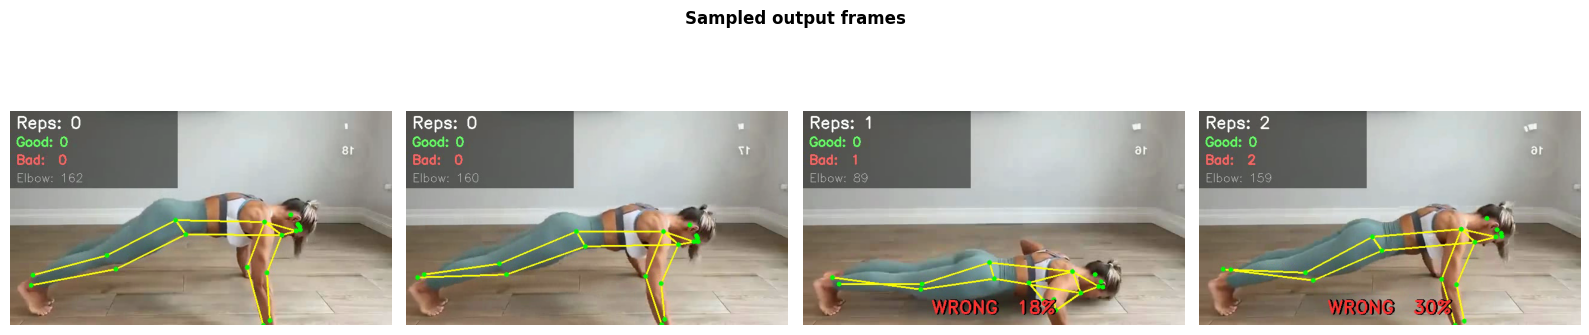

In [22]:
# ── 3.9  Preview first few frames of output ───────────────────────────────────
import matplotlib.pyplot as plt

cap2 = cv2.VideoCapture(OUTPUT_VIDEO)
frames_to_show = []
total = int(cap2.get(cv2.CAP_PROP_FRAME_COUNT))

# sample 4 evenly-spaced frames
sample_positions = [int(total * r) for r in [0.1, 0.35, 0.6, 0.85]]
for pos in sample_positions:
    cap2.set(cv2.CAP_PROP_POS_FRAMES, pos)
    ret, frm = cap2.read()
    if ret:
        frames_to_show.append(cv2.cvtColor(frm, cv2.COLOR_BGR2RGB))
cap2.release()

if frames_to_show:
    fig, axes = plt.subplots(1, len(frames_to_show), figsize=(16, 4))
    for ax, frm in zip(axes, frames_to_show):
        ax.imshow(frm); ax.axis('off')
    plt.suptitle('Sampled output frames', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(MODEL_DIR / 'output_preview.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('No output frames to preview.')